# Feature Importance — Universal Segmentation & Root Models

Loads the pickled universal models, extracts LogisticRegression coefficients,
and visualises which features have the highest influence on predictions.

In [1]:
import sys, pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add source dir so pickle can find the segmentation/root_identification modules
sys.path.insert(0, str(Path("../src/2_1_segmentation").resolve()))

MODEL_DIR = Path("../../data/2_1_segmentation/models")

with open(MODEL_DIR / "universal_seg.pkl", "rb") as f:
    seg_model = pickle.load(f)
with open(MODEL_DIR / "universal_root.pkl", "rb") as f:
    root_model = pickle.load(f)

print(f"Segmentation model: {len(seg_model.vec.feature_names_)} features")
print(f"Root model: {len(root_model.vec.feature_names_)} features")

Segmentation model: 56653 features
Root model: 9020 features


## 1. Segmentation Model — Top Features

In [4]:
def get_top_features(clf, vec, top_n=30):
    """Return top positive and negative features by coefficient magnitude."""
    names = np.array(vec.feature_names_)
    # Binary classifier: coef_ is (1, n_features)
    coefs = clf.coef_.ravel()
    
    # Top positive (push towards boundary / root)
    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
    # Top negative (push away from boundary / root)
    top_neg_idx = np.argsort(coefs)[:top_n]
    
    return names, coefs, top_pos_idx, top_neg_idx


def _safe_label(s):
    """Escape $ in feature names so matplotlib doesn't treat them as LaTeX."""
    return s.replace("$", r"\$")


def plot_top_features(clf, vec, title, top_n=30):
    names, coefs, top_pos_idx, top_neg_idx = get_top_features(clf, vec, top_n)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(8, top_n * 0.3)))
    
    # Positive
    ax1.barh(range(top_n), coefs[top_pos_idx][::-1], color="#2ecc71")
    ax1.set_yticks(range(top_n))
    ax1.set_yticklabels([_safe_label(n) for n in names[top_pos_idx][::-1]], fontsize=8)
    ax1.set_xlabel("Coefficient")
    ax1.set_title(f"{title} — Top {top_n} positive (pro-split/root)")
    
    # Negative
    ax2.barh(range(top_n), coefs[top_neg_idx][::-1], color="#e74c3c")
    ax2.set_yticks(range(top_n))
    ax2.set_yticklabels([_safe_label(n) for n in names[top_neg_idx][::-1]], fontsize=8)
    ax2.set_xlabel("Coefficient")
    ax2.set_title(f"{title} — Top {top_n} negative (anti-split/root)")
    
    plt.tight_layout()
    plt.show()

C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Tonda\AppData\Local\Program

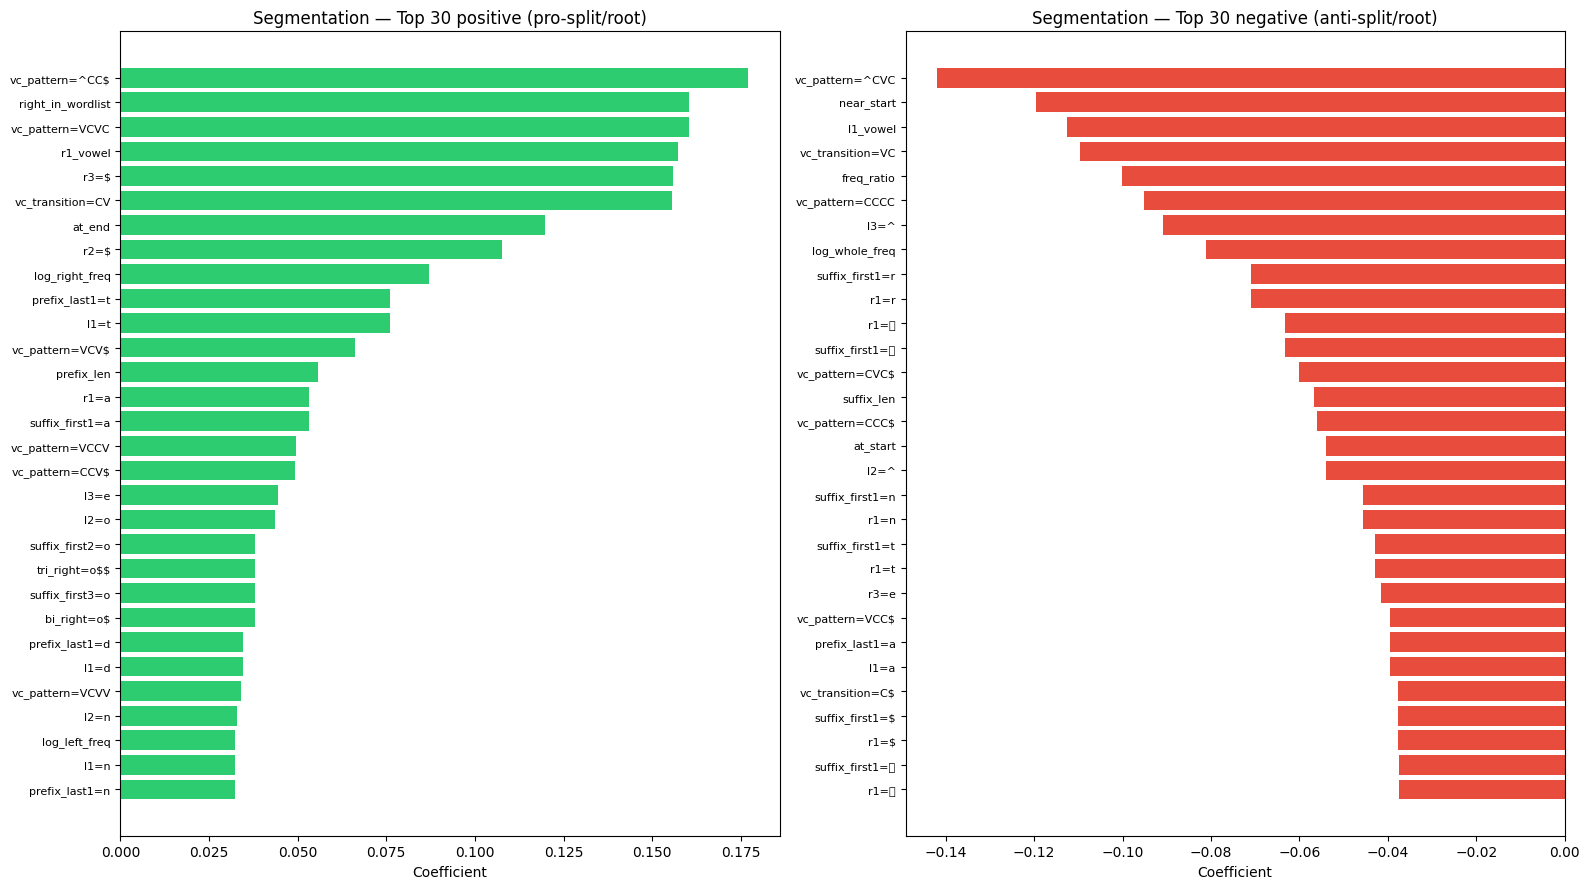

In [5]:
plot_top_features(seg_model.clf, seg_model.vec, "Segmentation")

## 2. Root Identification Model — Top Features

C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Tonda\AppData\Local\Temp\ipykernel_25288\2983697099.py:39: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\c

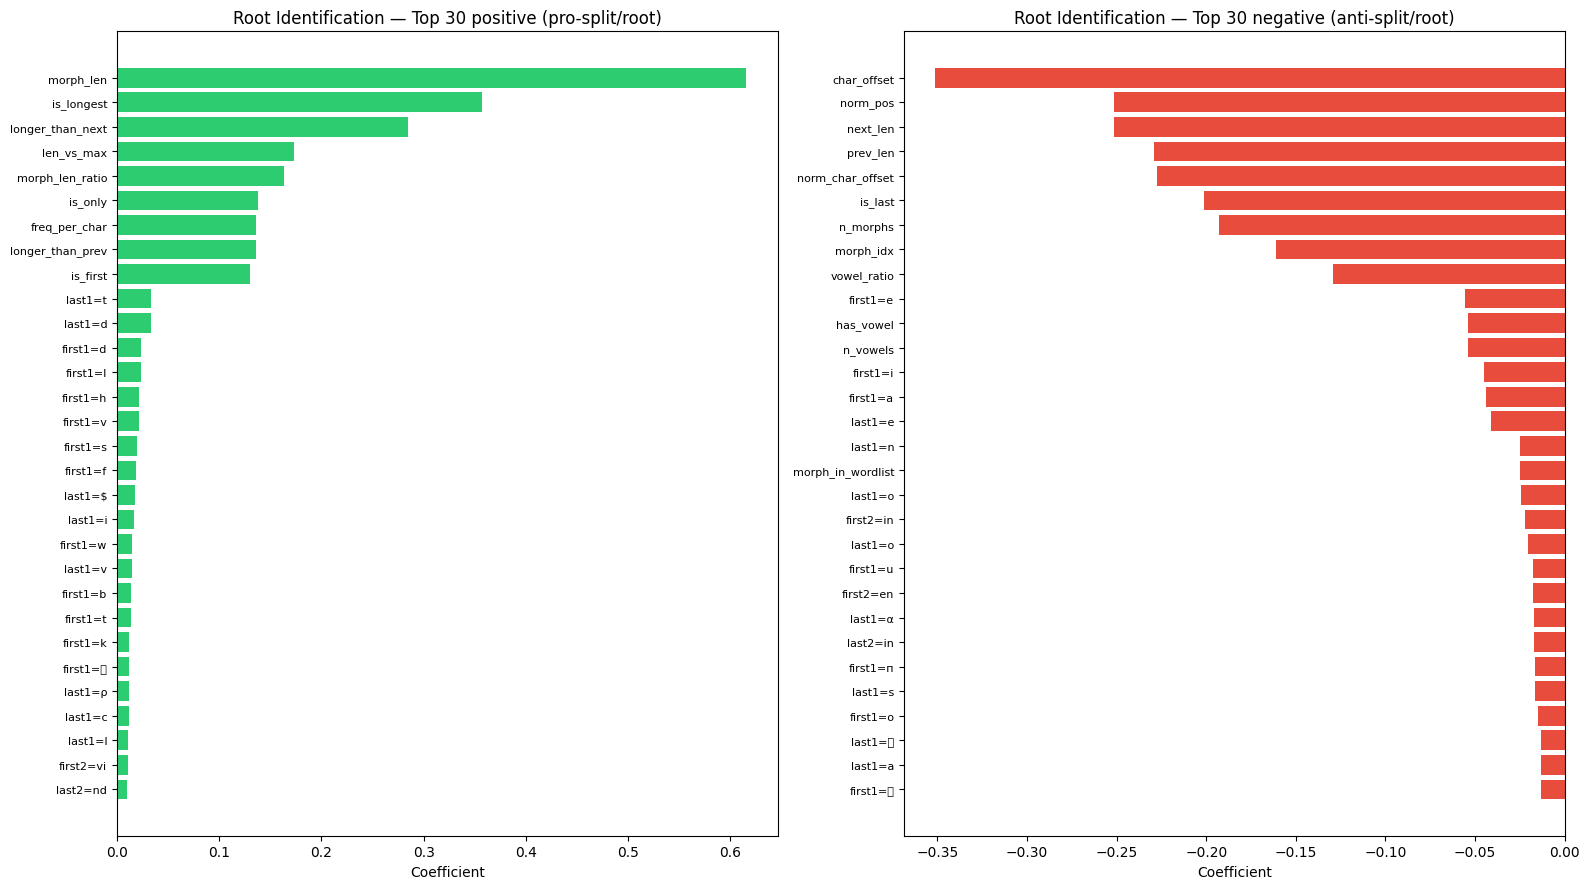

In [6]:
plot_top_features(root_model.clf, root_model.vec, "Root Identification")

## 3. Feature Category Importance

Group features by category and show the total absolute coefficient weight per category.

In [7]:
def categorize_seg_feature(name):
    """Map a segmentation feature name to its category."""
    if name.startswith(("l1=", "l2=", "l3=", "r1=", "r2=", "r3=")):
        return "Character window"
    if name.startswith(("bi_", "tri_")):
        return "Character n-grams"
    if name.startswith("vc_") or name in ("l1_vowel", "r1_vowel"):
        return "Vowel/consonant"
    if name.startswith(("prefix_last", "suffix_first")):
        return "Prefix/suffix n-grams"
    if name in ("prefix_len", "suffix_len", "word_len"):
        return "Length"
    if name.startswith(("norm_pos", "at_", "near_")):
        return "Position"
    if "freq" in name or "wordlist" in name:
        return "Frequency"
    return "Other"


def categorize_root_feature(name):
    """Map a root identification feature name to its category."""
    if name.startswith(("morph_len",)):
        return "Morph length"
    if name in ("n_morphs", "morph_idx", "is_first", "is_last", "is_only",
                "char_offset", "norm_char_offset") or name.startswith("norm_pos"):
        return "Position"
    if name.startswith(("first", "last")):
        return "Character n-grams"
    if name.startswith(("n_vowels", "has_vowel", "vowel_ratio")):
        return "Vowel content"
    if name in ("is_longest", "len_vs_max"):
        return "Relative size"
    if name in ("prev_len", "longer_than_prev", "next_len", "longer_than_next"):
        return "Context"
    if "freq" in name or "wordlist" in name:
        return "Frequency"
    return "Other"


def plot_category_importance(clf, vec, categorize_fn, title):
    names = vec.feature_names_
    coefs = np.abs(clf.coef_.ravel())
    
    categories = {}
    cat_counts = {}
    for name, c in zip(names, coefs):
        cat = categorize_fn(name)
        categories[cat] = categories.get(cat, 0) + c
        cat_counts[cat] = cat_counts.get(cat, 0) + 1
    
    # Sort by total importance
    sorted_cats = sorted(categories.items(), key=lambda x: x[1], reverse=True)
    cat_names = [f"{c[0]} ({cat_counts[c[0]]} feats)" for c in sorted_cats]
    cat_vals = [c[1] for c in sorted_cats]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(cat_names) * 0.5)))
    bars = ax.barh(range(len(cat_names)), cat_vals[::-1], color="#3498db")
    ax.set_yticks(range(len(cat_names)))
    ax.set_yticklabels(cat_names[::-1], fontsize=10)
    ax.set_xlabel("Sum of |coefficient|")
    ax.set_title(f"{title} — Importance by Feature Category")
    plt.tight_layout()
    plt.show()

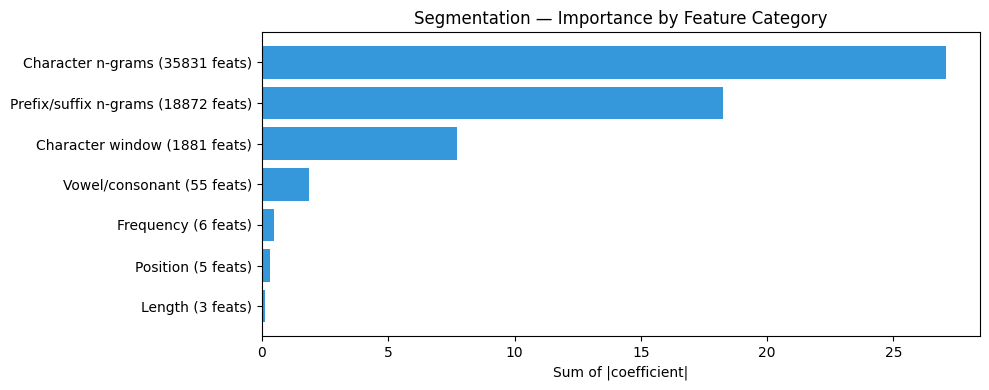

In [8]:
plot_category_importance(seg_model.clf, seg_model.vec, categorize_seg_feature, "Segmentation")

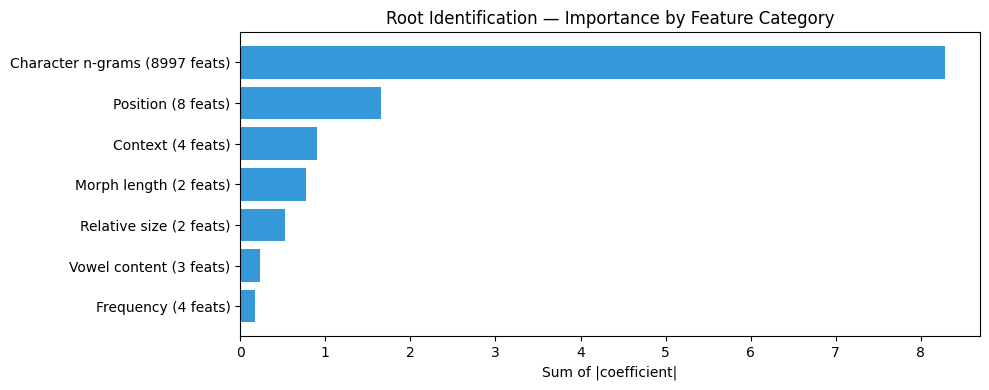

In [9]:
plot_category_importance(root_model.clf, root_model.vec, categorize_root_feature, "Root Identification")

## 3b. Mean Importance per Category & Individual Frequency Features

The sum-of-|coef| chart above is dominated by n-gram categories because they have thousands of one-hot features. A fairer comparison is **mean |coefficient| per feature** within each category, plus a direct look at each frequency feature's coefficient.

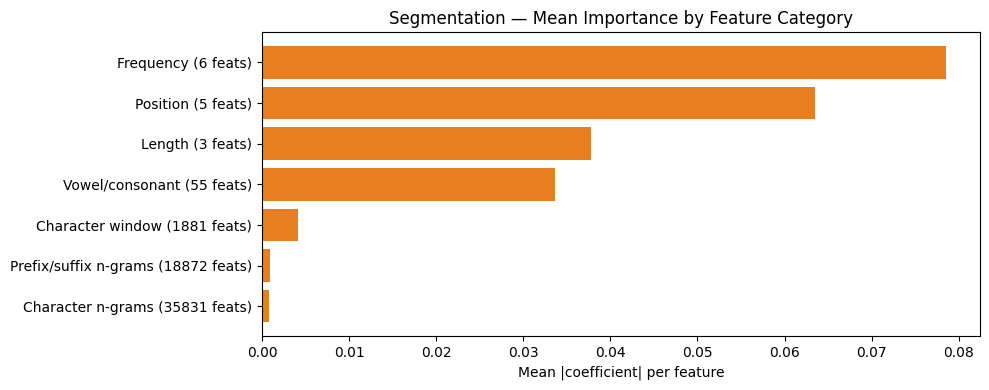

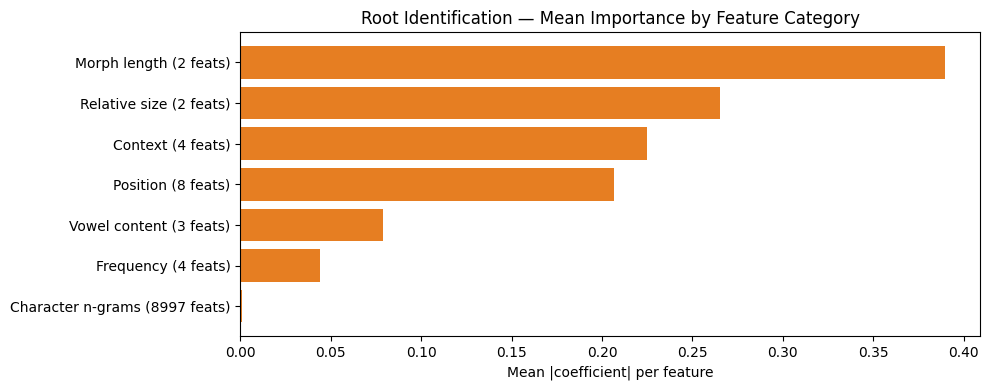

In [10]:
def plot_mean_category_importance(clf, vec, categorize_fn, title):
    names = vec.feature_names_
    coefs = np.abs(clf.coef_.ravel())
    
    cat_sum = {}
    cat_count = {}
    for name, c in zip(names, coefs):
        cat = categorize_fn(name)
        cat_sum[cat] = cat_sum.get(cat, 0) + c
        cat_count[cat] = cat_count.get(cat, 0) + 1
    
    # Mean importance
    cat_mean = {k: cat_sum[k] / cat_count[k] for k in cat_sum}
    sorted_cats = sorted(cat_mean.items(), key=lambda x: x[1], reverse=True)
    cat_names = [f"{c[0]} ({cat_count[c[0]]} feats)" for c in sorted_cats]
    cat_vals = [c[1] for c in sorted_cats]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(cat_names) * 0.5)))
    ax.barh(range(len(cat_names)), cat_vals[::-1], color="#e67e22")
    ax.set_yticks(range(len(cat_names)))
    ax.set_yticklabels(cat_names[::-1], fontsize=10)
    ax.set_xlabel("Mean |coefficient| per feature")
    ax.set_title(f"{title} — Mean Importance by Feature Category")
    plt.tight_layout()
    plt.show()


plot_mean_category_importance(seg_model.clf, seg_model.vec, categorize_seg_feature, "Segmentation")
plot_mean_category_importance(root_model.clf, root_model.vec, categorize_root_feature, "Root Identification")

In [11]:
# Show each frequency feature's individual coefficient
print("=== SEGMENTATION — Frequency Features ===")
seg_names = np.array(seg_model.vec.feature_names_)
seg_coefs = seg_model.clf.coef_.ravel()
for i, name in enumerate(seg_names):
    if "freq" in name or "wordlist" in name:
        print(f"  {name:25s}  coef={seg_coefs[i]:+.4f}  |coef|={abs(seg_coefs[i]):.4f}")

print(f"\n  (for reference: mean |coef| across all {len(seg_coefs)} features = {np.abs(seg_coefs).mean():.4f})")
print(f"  (median |coef| = {np.median(np.abs(seg_coefs)):.4f})")

print("\n=== ROOT IDENTIFICATION — Frequency Features ===")
root_names = np.array(root_model.vec.feature_names_)
root_coefs = root_model.clf.coef_.ravel()
for i, name in enumerate(root_names):
    if "freq" in name or "wordlist" in name:
        print(f"  {name:25s}  coef={root_coefs[i]:+.4f}  |coef|={abs(root_coefs[i]):.4f}")

print(f"\n  (for reference: mean |coef| across all {len(root_coefs)} features = {np.abs(root_coefs).mean():.4f})")
print(f"  (median |coef| = {np.median(np.abs(root_coefs)):.4f})")

=== SEGMENTATION — Frequency Features ===
  freq_ratio                 coef=-0.1002  |coef|=0.1002
  left_in_wordlist           coef=-0.0098  |coef|=0.0098
  log_left_freq              coef=+0.0325  |coef|=0.0325
  log_right_freq             coef=+0.0871  |coef|=0.0871
  log_whole_freq             coef=-0.0811  |coef|=0.0811
  right_in_wordlist          coef=+0.1605  |coef|=0.1605

  (for reference: mean |coef| across all 56653 features = 0.0010)
  (median |coef| = 0.0004)

=== ROOT IDENTIFICATION — Frequency Features ===
  freq_per_char              coef=+0.1362  |coef|=0.1362
  log_morph_freq             coef=-0.0124  |coef|=0.0124
  log_word_freq              coef=-0.0034  |coef|=0.0034
  morph_in_wordlist          coef=-0.0251  |coef|=0.0251

  (for reference: mean |coef| across all 9020 features = 0.0014)
  (median |coef| = 0.0004)


## 3c. Language Bias Analysis

Are the top features universal or dominated by specific training languages?
We load the training data, extract features per language, and check:
1. How many training examples each language contributes
2. Which languages use each top feature most often
3. What the model looks like if we only consider "universal" numeric features (no character n-grams)

In [12]:
import os, csv
from collections import Counter
from segmentation import load_segmented_words, extract_gap_features, load_frequency_map

TRAIN_DIR = Path("../../data/2_1_segmentation/training_data")
FREQ_DIR = Path("../../data/1_aggregated")

# Load training data and count examples + feature occurrences per language
lang_example_counts = {}
lang_feature_counts = {}  # {lang: Counter of feature names}

for morf in sorted(TRAIN_DIR.glob("*.morf")):
    lang = morf.stem
    words = load_segmented_words(str(morf))  # returns ["za hrad a", ...] (spaces = boundaries)
    freq_path = FREQ_DIR / f"{lang}.csv"
    freq_map = load_frequency_map(str(freq_path)) if freq_path.exists() else None
    
    n_examples = 0
    feat_counter = Counter()
    for seg_word in words:
        plain = seg_word.replace(" ", "")
        if len(plain) < 2:
            continue
        for gap_idx in range(len(plain) - 1):
            feats = extract_gap_features(plain, gap_idx, freq_map)
            n_examples += 1
            # Count which string-valued features (n-grams) appear
            for k, v in feats.items():
                if isinstance(v, str):
                    feat_counter[f"{k}={v}"] += 1
                else:
                    feat_counter[k] += 1
    
    lang_example_counts[lang] = n_examples
    lang_feature_counts[lang] = feat_counter
    print(f"  {lang}: {n_examples:>8,} gap examples, {len(words):>6,} words")

total = sum(lang_example_counts.values())
print(f"\nTotal: {total:,} gap examples")
print("\nTraining data share per language:")
for lang, count in sorted(lang_example_counts.items(), key=lambda x: -x[1]):
    print(f"  {lang}: {count:>8,}  ({100*count/total:.1f}%)")

  ces:    2,872 gap examples,    533 words
  deu:    1,087 gap examples,    199 words
  ell:    1,365 gap examples,    207 words
  eng:      902 gap examples,    200 words
  epo:      947 gap examples,    196 words
  fra:    1,080 gap examples,    200 words
  hin:      679 gap examples,    200 words
  jap:      342 gap examples,    200 words
  lat:    1,158 gap examples,    191 words
  mar:    1,018 gap examples,    201 words
  rus:    1,006 gap examples,    199 words
  spa:    1,117 gap examples,    200 words
  tel:    1,231 gap examples,    200 words

Total: 14,804 gap examples

Training data share per language:
  ces:    2,872  (19.4%)
  ell:    1,365  (9.2%)
  tel:    1,231  (8.3%)
  lat:    1,158  (7.8%)
  spa:    1,117  (7.5%)
  deu:    1,087  (7.3%)
  fra:    1,080  (7.3%)
  mar:    1,018  (6.9%)
  rus:    1,006  (6.8%)
  epo:      947  (6.4%)
  eng:      902  (6.1%)
  hin:      679  (4.6%)
  jap:      342  (2.3%)


In [13]:
# For top 30 segmentation features by |coef|, show which languages they come from
top50_idx = np.argsort(-np.abs(seg_coefs))[:50]
top50_names = seg_names[top50_idx]

print("Top 50 segmentation features — origin by language:\n")
print(f"  {'Feature':35s} {'|coef|':>7s}  Language breakdown")
print(f"  {'-'*35} {'-'*7}  {'-'*50}")

for feat_name in top50_names:
    idx = np.where(seg_names == feat_name)[0][0]
    coef_val = abs(seg_coefs[idx])
    
    # How many times does this feature appear in each language's training data?
    lang_counts = {}
    for lang, fc in lang_feature_counts.items():
        if feat_name in fc:
            lang_counts[lang] = fc[feat_name]
    
    if not lang_counts:
        print(f"  {feat_name:35s} {coef_val:7.4f}  (numeric feature — all languages)")
        continue
    
    total_feat = sum(lang_counts.values())
    # Show top 3 contributing languages
    top3 = sorted(lang_counts.items(), key=lambda x: -x[1])[:3]
    breakdown = ", ".join(f"{l}:{100*c/total_feat:.0f}%" for l, c in top3)
    n_langs = len(lang_counts)
    print(f"  {feat_name:35s} {coef_val:7.4f}  [{n_langs} langs] {breakdown}")

Top 50 segmentation features — origin by language:

  Feature                              |coef|  Language breakdown
  ----------------------------------- -------  --------------------------------------------------
  vc_pattern=^CC$                      0.1771  [8 langs] jap:83%, hin:6%, mar:3%
  right_in_wordlist                    0.1605  [12 langs] ces:20%, ell:9%, tel:9%
  vc_pattern=VCVC                      0.1603  [12 langs] ces:26%, ell:15%, lat:12%
  r1_vowel                             0.1572  [13 langs] ces:19%, ell:9%, tel:8%
  r3=$                                 0.1558  [13 langs] ces:18%, ell:7%, deu:7%
  vc_transition=CV                     0.1556  [13 langs] ces:24%, ell:11%, spa:9%
  vc_pattern=^CVC                      0.1420  [13 langs] ces:25%, spa:9%, lat:9%
  at_end                               0.1197  [13 langs] ces:19%, ell:9%, tel:8%
  near_start                           0.1195  [13 langs] ces:19%, ell:9%, tel:8%
  l1_vowel                             0.112

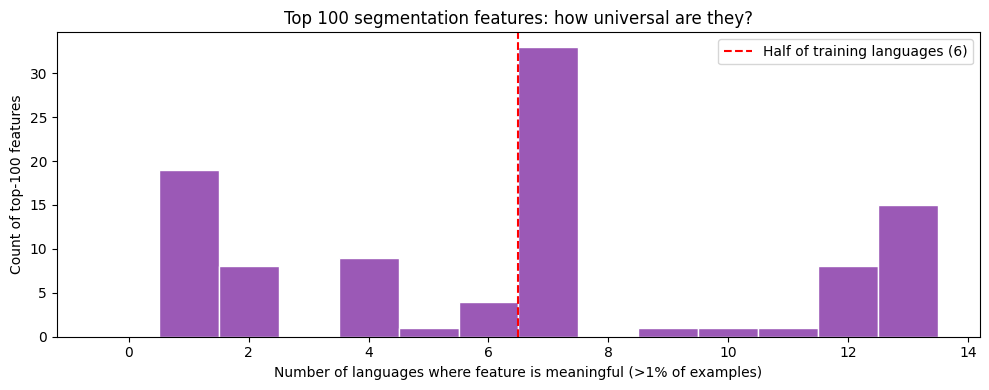


Of top 100 features:
  63 appear in ≥ half the training languages (universal)
  27 appear in ≤ 2 languages (language-specific)


In [14]:
# Visualize: how many of the top 100 features are language-specific vs shared?
top100_idx = np.argsort(-np.abs(seg_coefs))[:100]
top100_names = seg_names[top100_idx]

n_langs_per_feat = []
for feat_name in top100_names:
    lang_counts = {lang: fc[feat_name] for lang, fc in lang_feature_counts.items() if feat_name in fc}
    if not lang_counts:
        n_langs_per_feat.append(len(lang_feature_counts))  # numeric — all langs
    else:
        # Count languages where feature appears in >1% of that language's examples
        n_meaningful = sum(1 for lang, cnt in lang_counts.items() 
                          if cnt / lang_example_counts[lang] > 0.01)
        n_langs_per_feat.append(n_meaningful)

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, len(lang_feature_counts) + 2)
ax.hist(n_langs_per_feat, bins=bins, color="#9b59b6", edgecolor="white", align="left")
ax.set_xlabel("Number of languages where feature is meaningful (>1% of examples)")
ax.set_ylabel("Count of top-100 features")
ax.set_title("Top 100 segmentation features: how universal are they?")
ax.axvline(x=len(lang_feature_counts)/2, color="red", linestyle="--", 
           label=f"Half of training languages ({len(lang_feature_counts)//2})")
ax.legend()
plt.tight_layout()
plt.show()

# Summary
n_universal = sum(1 for n in n_langs_per_feat if n >= len(lang_feature_counts) // 2)
n_narrow = sum(1 for n in n_langs_per_feat if n <= 2)
print(f"\nOf top 100 features:")
print(f"  {n_universal} appear in ≥ half the training languages (universal)")
print(f"  {n_narrow} appear in ≤ 2 languages (language-specific)")

## 4. Feature Count and Sparsity

In [15]:
for label, model in [("Segmentation", seg_model), ("Root", root_model)]:
    coefs = model.clf.coef_.ravel()
    n_total = len(coefs)
    n_nonzero = np.count_nonzero(coefs)
    n_near_zero = np.sum(np.abs(coefs) < 0.01)
    print(f"{label}: {n_total} features total, {n_nonzero} non-zero, "
          f"{n_near_zero} near-zero (|c| < 0.01)")
    print(f"  Coefficient range: [{coefs.min():.4f}, {coefs.max():.4f}]")
    print(f"  Mean |coef|: {np.abs(coefs).mean():.4f}")
    print()

Segmentation: 56653 features total, 56653 non-zero, 56159 near-zero (|c| < 0.01)
  Coefficient range: [-0.1420, 0.1771]
  Mean |coef|: 0.0010

Root: 9020 features total, 9020 non-zero, 8934 near-zero (|c| < 0.01)
  Coefficient range: [-0.3510, 0.6155]
  Mean |coef|: 0.0014



## 5. Per-Language Model Comparison

Compare top features of language-specific models vs the universal model.

In [16]:
# Load all per-language segmentation models
lang_models = {}
for pkl in sorted(MODEL_DIR.glob("*_seg.pkl")):
    lang = pkl.stem.replace("_seg", "")
    if lang == "universal":
        continue
    with open(pkl, "rb") as f:
        lang_models[lang] = pickle.load(f)

print(f"Loaded {len(lang_models)} per-language segmentation models: {list(lang_models.keys())}")

c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DictVectorizer from version 1.4.1.post1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Tonda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.1.post1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded 12 per-language segmentation models: ['ces', 'deu', 'ell', 'eng', 'fra', 'fre', 'hin', 'jap', 'lat', 'rus', 'spa', 'tel']


In [17]:
# For each language model, find its top-10 features and see how they rank in the universal model
uni_names = np.array(seg_model.vec.feature_names_)
uni_coefs = seg_model.clf.coef_.ravel()
uni_rank = {name: rank for rank, name in enumerate(
    uni_names[np.argsort(-np.abs(uni_coefs))])}

for lang, lm in lang_models.items():
    l_names = np.array(lm.vec.feature_names_)
    l_coefs = lm.clf.coef_.ravel()
    top10_idx = np.argsort(-np.abs(l_coefs))[:10]
    
    print(f"\n--- {lang.upper()} (top 10 by |coef|) ---")
    for idx in top10_idx:
        name = l_names[idx]
        coef = l_coefs[idx]
        u_rank = uni_rank.get(name, "N/A")
        u_rank_str = f"#{u_rank+1}" if isinstance(u_rank, int) else u_rank
        print(f"  {name:30s}  coef={coef:+.4f}  (universal rank: {u_rank_str})")


--- CES (top 10 by |coef|) ---
  vc_pattern=^CVC                 coef=-1.3940  (universal rank: #7)
  near_start                      coef=-1.3140  (universal rank: #9)
  vc_pattern=CCV$                 coef=+1.2136  (universal rank: #34)
  bi_left=po                      coef=+1.1869  (universal rank: #645)
  prefix_last2=po                 coef=+1.1869  (universal rank: #644)
  bi_cross=st                     coef=-1.1477  (universal rank: #170)
  tri_wide=^na                    coef=+1.0652  (universal rank: #1749)
  prefix_last3=na                 coef=+1.0652  (universal rank: #1748)
  vc_pattern=VCC$                 coef=-1.0544  (universal rank: #42)
  bi_cross=al                     coef=+0.9919  (universal rank: #378)

--- DEU (top 10 by |coef|) ---
  right_in_wordlist               coef=+1.2229  (universal rank: #2)
  tri_right=er$                   coef=+1.0569  (universal rank: #534)
  suffix_first3=er                coef=+1.0569  (universal rank: #535)
  l3=i             